### ＡIプログラミング2 9,10回目<br>

# 1.手書き文字(MNIST)の読み込み

###(1)データの読み込み(MNISTを読み込む)

In [ ]:
from torchvision.datasets import MNIST
from torchvision import transforms

img_size = 28  # 画像の高さと幅

# 訓練データを取得
mnist_train = MNIST("./data",
                    train=True, download=True,
                    transform=transforms.ToTensor())  # Tensorに変換
# テストデータの取得
mnist_test = MNIST("./data",
                   train=False, download=True,
                   transform=transforms.ToTensor())  # Tensorに変換

print("訓練データの数:", len(mnist_train), "テストデータの数:", len(mnist_test))

100%|██████████| 9912422/9912422 [00:00<00:00, 354064852.54it/s]

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw


100%|██████████| 28881/28881 [00:00<00:00, 39509358.72it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 112161715.81it/s]

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 25199112.13it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

訓練データの数: 60000 テストデータの数: 10000


###(2)データローダの設定

In [ ]:
from torch.utils.data import DataLoader

# DataLoaderの設定
batch_size = 256  # バッチサイズ
train_loader = DataLoader(mnist_train,
                          batch_size=batch_size,
                          shuffle=True)
test_loader = DataLoader(mnist_test,
                         batch_size=batch_size,
                         shuffle=False)

###(3)モデルの構築

In [ ]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(img_size*img_size, 1024)  # 全結合層
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)
        self.relu = nn.ReLU()  # ReLU 学習するパラメータがないので使い回しできる

#forwardが重要(pytorchでは)
    def forward(self, x):
        x = x.view(-1, img_size*img_size)  # (バッチサイズ, 入力の数): 画像を1次元に変換
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()
#net.cuda()  # GPU対応
print(net)

Net(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)


### (4)ミニバッチによるモデルの学習

In [ ]:
from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# SGD
optimizer = optim.SGD(net.parameters(), lr=0.01)

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
for i in range(8):  # 8エポック学習
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
#        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    net.eval()  # 評価モード
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):  # ミニバッチ（x, t）を取り出す
#        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)

Epoch: 0 Loss_Train: 2.2283411695602093 Loss_Test: 2.1160105049610136
Epoch: 1 Loss_Train: 1.8724154091895895 Loss_Test: 1.5070260107517242
Epoch: 2 Loss_Train: 1.1739008302384235 Loss_Test: 0.8708730489015579
Epoch: 3 Loss_Train: 0.750407771354026 Loss_Test: 0.6164241559803486
Epoch: 4 Loss_Train: 0.5779872638113955 Loss_Test: 0.5028785921633243
Epoch: 5 Loss_Train: 0.4921834792228455 Loss_Test: 0.43975369110703466
Epoch: 6 Loss_Train: 0.44154810702547115 Loss_Test: 0.4003342442214489
Epoch: 7 Loss_Train: 0.4083185272013887 Loss_Test: 0.3735122257843614


###(5)誤差をグラフに

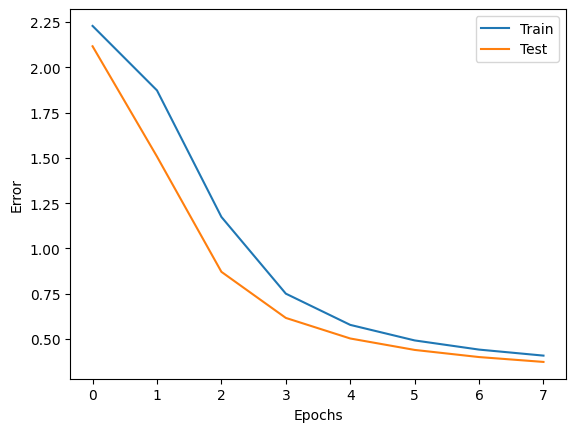

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

###(6)正解率の計算

In [ ]:
count = 0
total = 0
net.eval()  # 評価モード

#ミニバッチ分取り出す
for i, (x, t) in enumerate(test_loader):
#    x, t = x.cuda(), t.cuda()  # GPU対応
    y = net(x)    #まとめて予測

    #予測1つずつを正解と比較
    for j, y_j in enumerate(y):
      y_label=y_j.argmax().item()
      t_label=t[j].item()

      #予測と正解ラベルが同じだったらカウントアップ
      if y_label ==t_label:
        count+=1

    total += len(x)  #miniバッチ分ごとに合計
print("正解率:", str(count/total))

正解率: 0.8964


#課題1<br>


Epoch: 0 Loss_Train: 2.288399592866289 Loss_Test: 2.2720092475414275
Epoch: 1 Loss_Train: 2.244842942217563 Loss_Test: 2.2013891994953156
Epoch: 2 Loss_Train: 2.100976270817696 Loss_Test: 1.9281142145395278
Epoch: 3 Loss_Train: 1.5910259064207686 Loss_Test: 1.184162199497223
Epoch: 4 Loss_Train: 0.9561025819879897 Loss_Test: 0.7688467495143414
Epoch: 5 Loss_Train: 0.6965031037939355 Loss_Test: 0.6117017239332199
Epoch: 6 Loss_Train: 0.5735625211228715 Loss_Test: 0.5140391908586025
Epoch: 7 Loss_Train: 0.4969652465049257 Loss_Test: 0.45132199600338935
Epoch: 8 Loss_Train: 0.447563965650315 Loss_Test: 0.41607108656316993
Epoch: 9 Loss_Train: 0.4128046868963445 Loss_Test: 0.3830091094598174


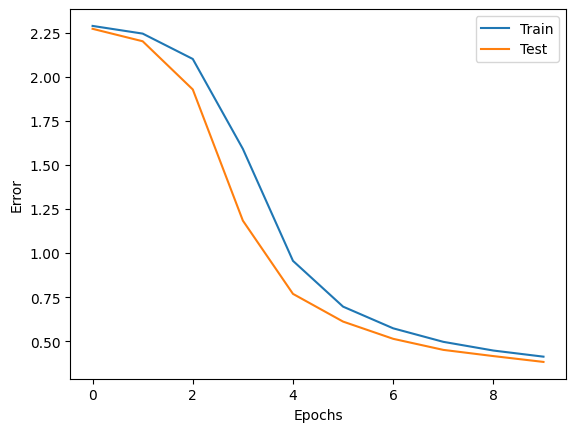

正解率: 0.8884


In [ ]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(img_size*img_size, 1024)  # 全結合層
        self.fc2 = nn.Linear(1024, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 10)
        self.relu = nn.ReLU()  # ReLU 学習するパラメータがないので使い回しできる

#forwardが重要(pytorchでは)
    def forward(self, x):
        x = x.view(-1, img_size*img_size)  # (バッチサイズ, 入力の数): 画像を1次元に変換
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc4(x))
        x = self.fc3(x)
        return x

net = Net()
#net.cuda()  # GPU対応
#print(net)

from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# SGD
optimizer = optim.SGD(net.parameters(), lr=0.01)

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
for i in range(10):  # 10エポック学習
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
#        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    net.eval()  # 評価モード
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):  # ミニバッチ（x, t）を取り出す
#        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)


#誤差のグラフ化

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

##正解率の計算
count = 0
total = 0
net.eval()  # 評価モード

#ミニバッチ分取り出す
for i, (x, t) in enumerate(test_loader):
#    x, t = x.cuda(), t.cuda()  # GPU対応
    y = net(x)    #まとめて予測

    #予測1つずつを正解と比較
    for j, y_j in enumerate(y):
      y_label=y_j.argmax().item()
      t_label=t[j].item()

      #予測と正解ラベルが同じだったらカウントアップ
      if y_label ==t_label:
        count+=1

    total += len(x)  #miniバッチ分ごとに合計
print("正解率:", str(count/total))


# 2.CNN(畳み込みニューラルネットワーク)
Convlution Neural Network

##(1)画像データCIFA-10の読み込みとデータの加工

###(1)画像データの表示

100%|██████████| 170498071/170498071 [00:12<00:00, 13229240.82it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
データの数: 10000


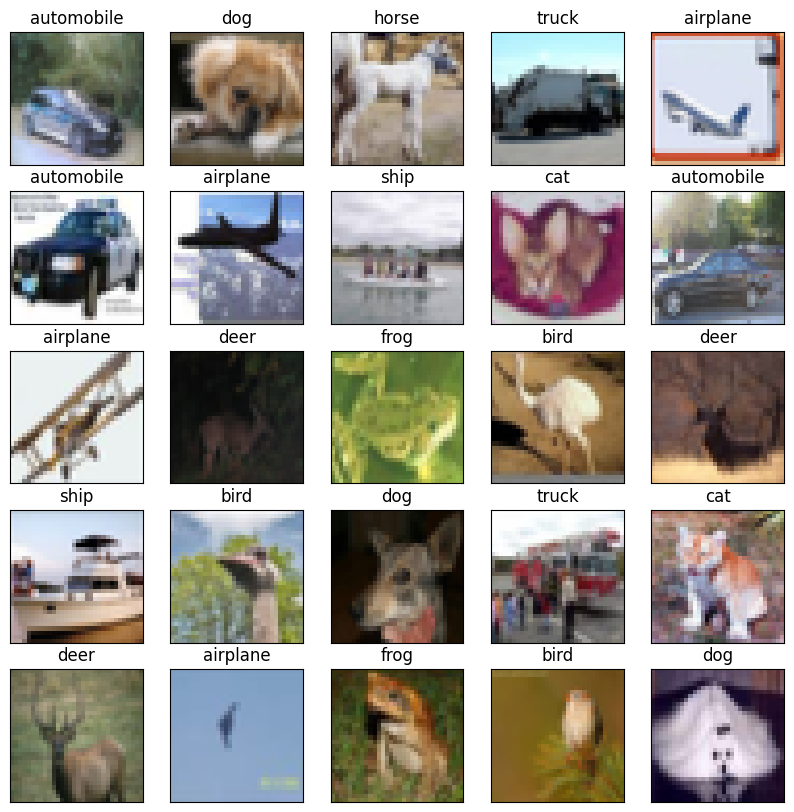

In [ ]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

cifar10_data = CIFAR10(root="./data",
                       train=False,download=True,
                       transform=transforms.ToTensor())
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]
print("データの数:", len(cifar10_data))

n_image = 25  # 表示する画像の数
cifar10_loader = DataLoader(cifar10_data, batch_size=n_image, shuffle=True)
dataiter = iter(cifar10_loader)  # イテレータ: 要素を順番に取り出せるようにする
#images, labels = dataiter.next()  # 最初のバッチを取り出す
images, labels = next(dataiter)

plt.figure(figsize=(10,10))  # 画像の表示サイズ
for i in range(n_image):
    ax = plt.subplot(5,5,i+1)
    ax.imshow(images[i].permute(1, 2, 0))  # チャンネルを一番後の次元に
    label = cifar10_classes[labels[i]]
    ax.set_title(label)
    ax.get_xaxis().set_visible(False)  # 軸を非表示に
    ax.get_yaxis().set_visible(False)

plt.show()

###(2)画像データのリサイズ

Files already downloaded and verified


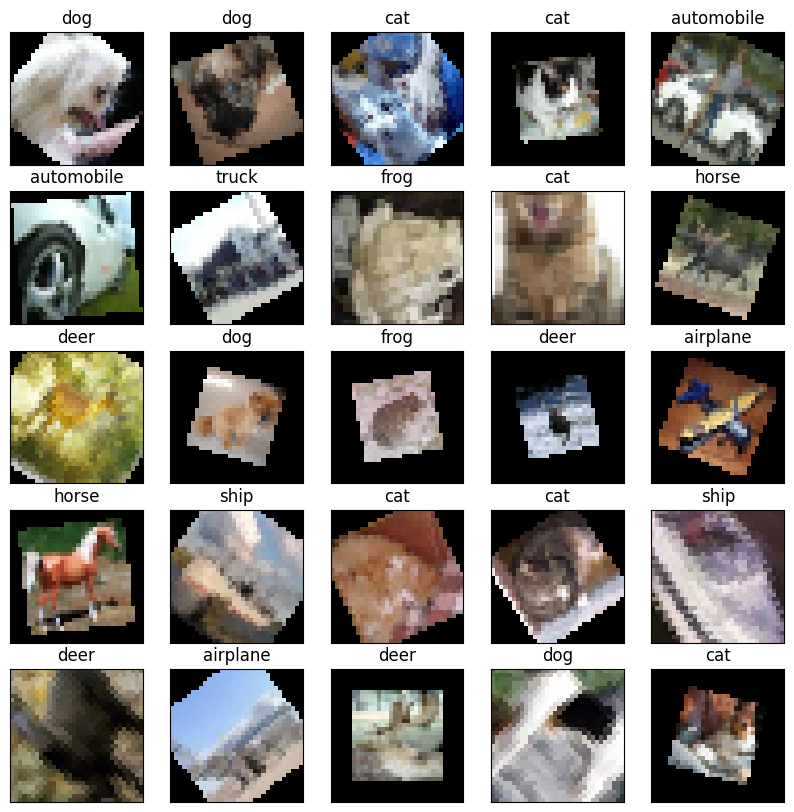

In [ ]:
transform = transforms.Compose([transforms.RandomAffine((-45, 45), scale=(0.5, 1.5)),  # 回転とリサイズ
                                transforms.ToTensor()])
cifar10_data = CIFAR10(root="./data",
                       train=False,download=True,
                       transform=transform)

cifar10_loader = DataLoader(cifar10_data, batch_size=n_image, shuffle=True)
dataiter = iter(cifar10_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10,10))  # 画像の表示サイズ
for i in range(n_image):
    ax = plt.subplot(5,5,i+1)
    ax.imshow(images[i].permute(1, 2, 0))
    label = cifar10_classes[labels[i]]
    ax.set_title(label)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

###(3)データの拡張シフト

Files already downloaded and verified


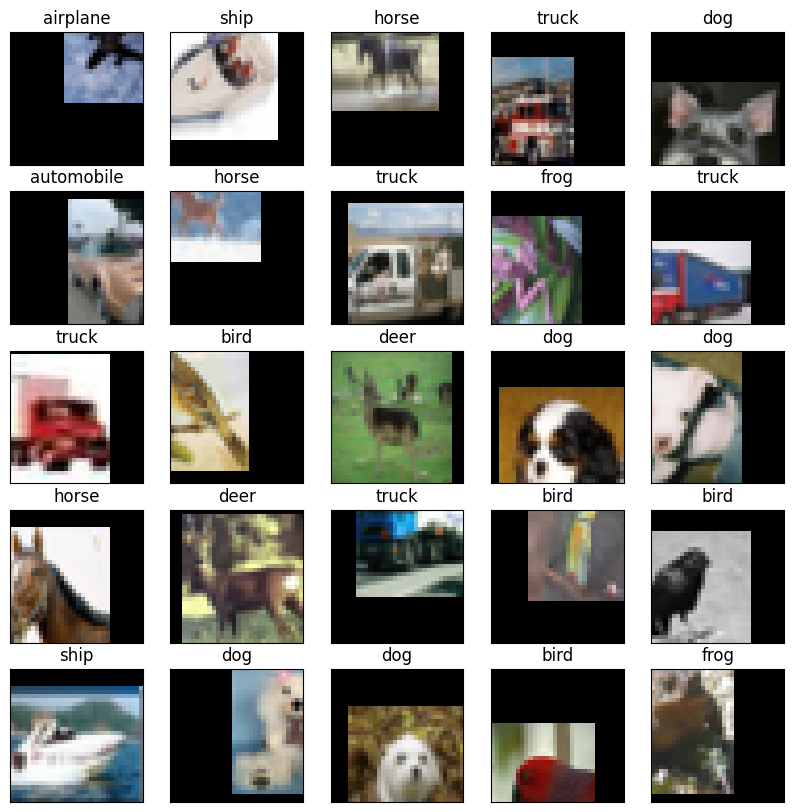

In [ ]:
transform = transforms.Compose([transforms.RandomAffine((0, 0), translate=(0.5, 0.5)),  # 上下左右へのシフト
                                transforms.ToTensor()])
cifar10_data = CIFAR10(root="./data",
                       train=False,download=True,
                       transform=transform)

cifar10_loader = DataLoader(cifar10_data, batch_size=n_image, shuffle=True)
dataiter = iter(cifar10_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10,10))  # 画像の表示サイズ
for i in range(n_image):
    ax = plt.subplot(5,5,i+1)
    ax.imshow(images[i].permute(1, 2, 0))
    label = cifar10_classes[labels[i]]
    ax.set_title(label)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

###データの反転

Files already downloaded and verified


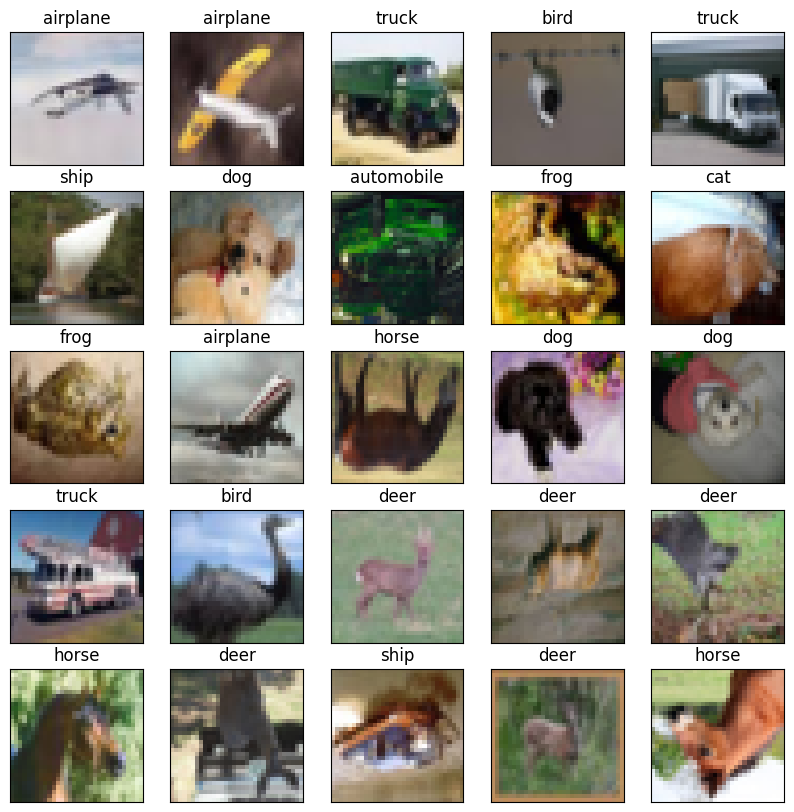

In [ ]:
transform = transforms.Compose([transforms.RandomHorizontalFlip(p=0.5),  # 左右反転
                                transforms.RandomVerticalFlip(p=0.5),  # 上下反転
                                transforms.ToTensor()])
cifar10_data = CIFAR10(root="./data",
                       train=False,download=True,
                       transform=transform)

cifar10_loader = DataLoader(cifar10_data, batch_size=n_image, shuffle=True)
dataiter = iter(cifar10_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10,10))  # 画像の表示サイズ
for i in range(n_image):
    ax = plt.subplot(5,5,i+1)
    ax.imshow(images[i].permute(1, 2, 0))
    label = cifar10_classes[labels[i]]
    ax.set_title(label)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

##(2)画像の学習

##(1)データの読み込み

In [ ]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

affine = transforms.RandomAffine((-30, 30), scale=(0.8, 1.2))  # 回転とリサイズ
flip = transforms.RandomHorizontalFlip(p=0.5)  # 左右反転
normalize = transforms.Normalize((0.0, 0.0, 0.0), (1.0, 1.0, 1.0))  # 平均値を0、標準偏差を1に
to_tensor = transforms.ToTensor()

transform_train = transforms.Compose([affine, flip, to_tensor, normalize])
transform_test = transforms.Compose([to_tensor, normalize])
cifar10_train = CIFAR10("./data", train=True, download=True, transform=transform_train)
cifar10_test = CIFAR10("./data", train=False, download=True, transform=transform_test)

# DataLoaderの設定
batch_size = 64
train_loader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


##(2)CNNモデルの構築

In [ ]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 5)  # 畳み込み層:(入力チャンネル数, フィルタ数、フィルタサイズ)
        self.relu = nn.ReLU()  # ReLU
        self.pool = nn.MaxPool2d(2, 2)  # プーリング層:（領域のサイズ, 領域の間隔）
        self.conv2 = nn.Conv2d(8, 16, 5)
        self.fc1 = nn.Linear(16*5*5, 256)  # 全結合層
        self.dropout = nn.Dropout(p=0.5)  # ドロップアウト:(p=ドロップアウト率)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 16*5*5)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

net = Net()
#net.cuda()  # GPU対応
print(net)

Net(
  (conv1): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


###(3)モデルの訓練

In [ ]:
from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
for i in range(20):  # 20エポック学習
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
    #    x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    net.eval()  # 評価モード
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):  # ミニバッチ（x, t）を取り出す
#        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)

Epoch: 0 Loss_Train: 1.8625188982090377 Loss_Test: 1.618510149846411
Epoch: 1 Loss_Train: 1.6483005683135499 Loss_Test: 1.461914929614705
Epoch: 2 Loss_Train: 1.5614098232725393 Loss_Test: 1.391075751584047
Epoch: 3 Loss_Train: 1.5136179248695179 Loss_Test: 1.3625797450922097
Epoch: 4 Loss_Train: 1.4846148038154368 Loss_Test: 1.3360707129642462
Epoch: 5 Loss_Train: 1.4522579079088958 Loss_Test: 1.3351365722668398
Epoch: 6 Loss_Train: 1.4336772131188142 Loss_Test: 1.2809555188865418
Epoch: 7 Loss_Train: 1.4107401284110515 Loss_Test: 1.2527012468143632
Epoch: 8 Loss_Train: 1.3957245322444556 Loss_Test: 1.266154294181022
Epoch: 9 Loss_Train: 1.3848913642756469 Loss_Test: 1.2455713547718752
Epoch: 10 Loss_Train: 1.3699751558816036 Loss_Test: 1.2077449613316045
Epoch: 11 Loss_Train: 1.3627323838298584 Loss_Test: 1.2237098122098644
Epoch: 12 Loss_Train: 1.3592402912161845 Loss_Test: 1.2012211908200743
Epoch: 13 Loss_Train: 1.3490726139082019 Loss_Test: 1.1669970674879233
Epoch: 14 Loss_Train

###(4)誤差をグラフ化と表示

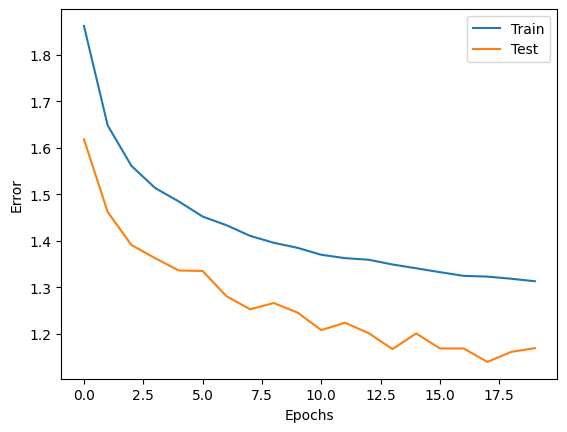

正解率: 58.56%


In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

#正解データの表示
correct = 0
total = 0
net.eval()  # 評価モード
for i, (x, t) in enumerate(test_loader):
#    x, t = x.cuda(), t.cuda()  # GPU対応
    y = net(x)
    correct += (y.argmax(1) == t).sum().item()
    total += len(x)
print("正解率:", str(correct/total*100) + "%")

###(5)正解したデータを表示してみる

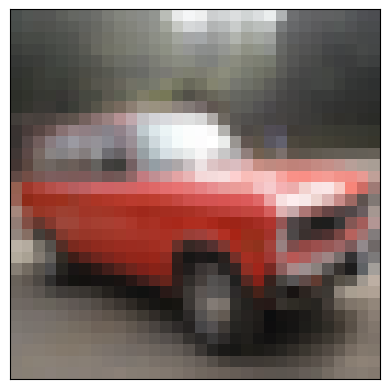

正解: automobile 予測結果: automobile


In [ ]:
cifar10_loader = DataLoader(cifar10_test, batch_size=1, shuffle=True)
dataiter = iter(cifar10_loader)
images, labels = next(dataiter)  # サンプルを1つだけ取り出す


#取り出したいデータ場所のインデックスの指定
ei=10

plt.imshow(images[0].permute(1, 2, 0))  # チャンネルを一番後ろに
plt.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)  # ラベルとメモリを非表示に
plt.show()

net.eval()  # 評価モード
#x, t = images.cuda(), labels.cuda()  # GPU対応
x, t = images, labels  # GPU対応無
y = net(x)
print("正解:", cifar10_classes[labels[0]],
      "予測結果:", cifar10_classes[y.argmax().item()])